In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import functions as f
import datetime as dt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cmocean as cm
import geopandas as gpd
import pandas as pd
import trajan

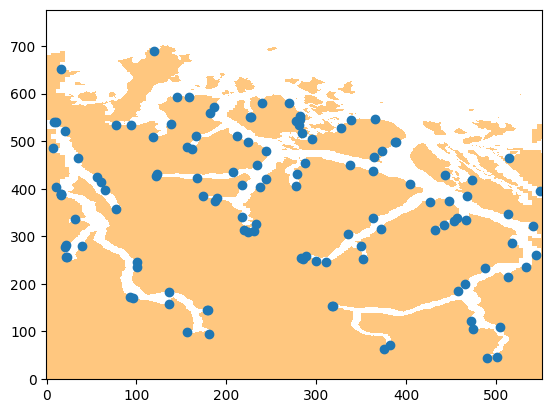

In [5]:
river = xr.open_dataset('/lustre/storeB/project/metproduction/products/roms/norkyst_v3/m70/norkyst_river_160_m70.nc')
nk160 = xr.open_dataset('symlink_m70/20240601-160.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask==1] = np.nan

plt.pcolormesh(nk160.xi_rho, nk160.eta_rho, mask, cmap='copper_r', shading='nearest')
plt.scatter(river.river_Xposition, river.river_Eposition)

In [6]:

with open('rivers_sulafjorden.txt', 'w') as f:
    for x, y in zip(river.river_Xposition, river.river_Eposition):
        if x.values >= 0 and y.values >= 0:
            lon = nk160.lon_rho.isel(eta_rho=int(y.values), xi_rho=int(x.values))
            lat = nk160.lat_rho.isel(eta_rho=int(y.values), xi_rho=int(x.values))
            f.write(f'{lon.values}, {lat.values}\n')

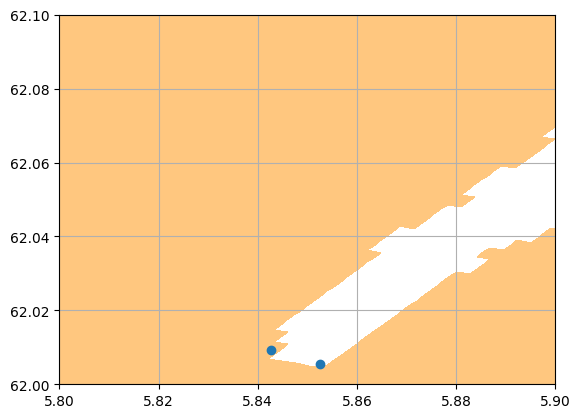

In [52]:

riv = pd.read_csv('rivers_sulafjorden.txt', names=['lon', 'lat'])
lon, lat = 6.122272968292236, 62.195274353027344
lon, lat = 6.118, 62.195
plt.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest')
plt.scatter(riv['lon'], riv['lat'])
plt.xlim(5.8,5.9)
plt.ylim(62,62.1)
plt.grid()
plt.scatter(lon, lat, color='r', zorder=10)

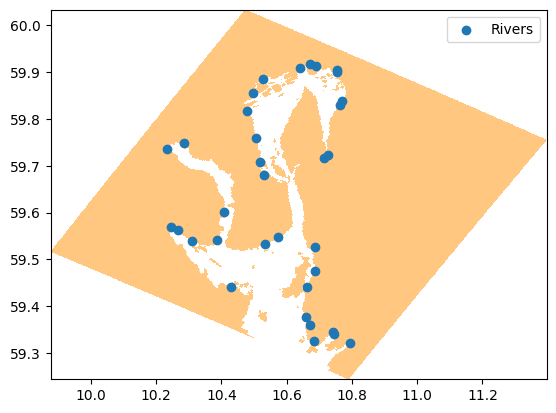

In [7]:

riv = pd.read_csv('rivers_oslofjorden.txt', names=['lon', 'lat'])
nk160 = xr.open_dataset('symlink_m71/20240601.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask==1] = np.nan
plt.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest')
plt.scatter(riv['lon'], riv['lat'], label='Rivers')
plt.legend()



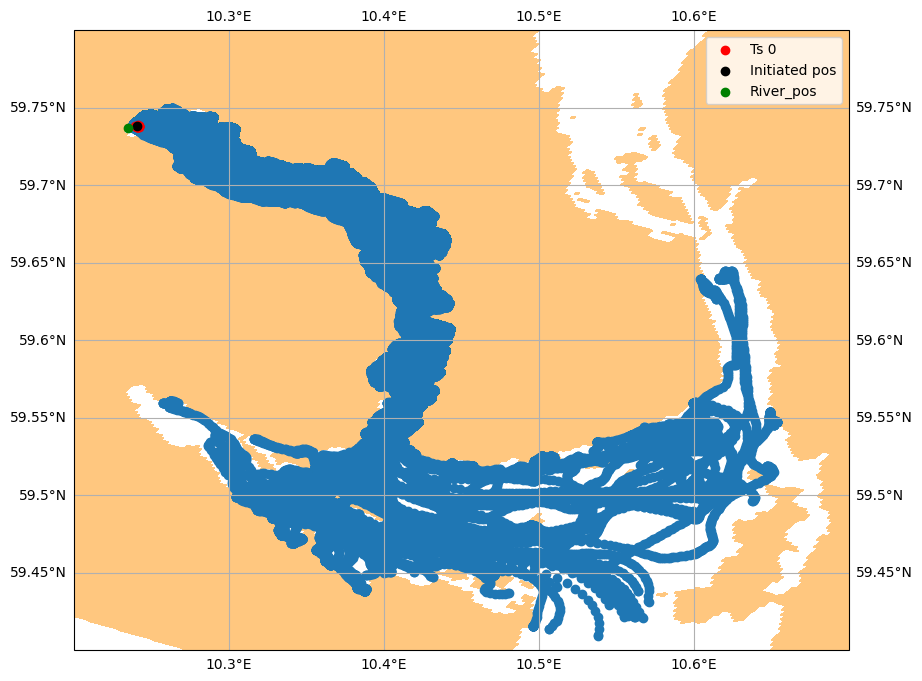

In [12]:


parts = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/drammen/river_plume_2025-09-16T06:00:00.nc')
riv_lon, riv_lat = 10.234757423400879, 59.737117767333984
lon, lat = 10.241, 59.738
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(parts.lon, parts.lat, transform=ccrs.PlateCarree())
ax.scatter(parts.lon.isel(time=0), parts.lat.isel(time=0), c='r', transform=ccrs.PlateCarree(), label='Ts 0')
ax.scatter(lon, lat, c='black', transform=ccrs.PlateCarree(), label='Initiated pos')
ax.scatter(riv_lon, riv_lat, c='green', transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([10.2,10.7,59.4,59.8], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)
ax.legend(loc='upper right')


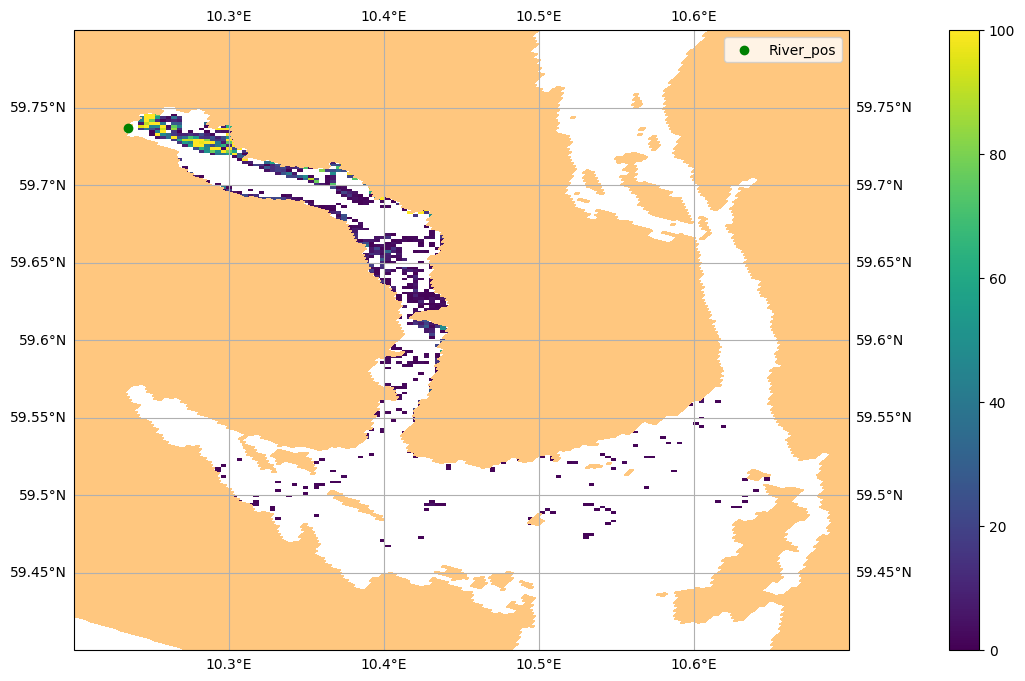

In [91]:

ds = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/drammen/river_plume_2025-09-16T06:00:00.nc')
nk160 = xr.open_dataset('symlink_m71/20240602.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask==1] = np.nan

riv_lon, riv_lat = 10.234757423400879, 59.737117767333984
lon, lat = 10.241, 59.738
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
c = ax.pcolormesh(ds.c_lon, ds.c_lat, ds.number.isel(time=-1), transform=ccrs.PlateCarree(), vmin=0, vmax=100)
#ax.scatter(ds.lon.isel(time=-1), ds.lat.isel(time=-1), transform=ccrs.PlateCarree(), s=2)
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(riv_lon, riv_lat, c='green', transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([10.2,10.7,59.4,59.8], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)
ax.legend(loc='upper right')
cax = fig.add_axes([ax.get_position().x1+0.1, ax.get_position().y0, 0.030, ax.get_position().height])
cbar = fig.colorbar(c, ax=ax, cax=cax)

Text(0.5, 1.0, 'No vertical advection, 2024-09-18')

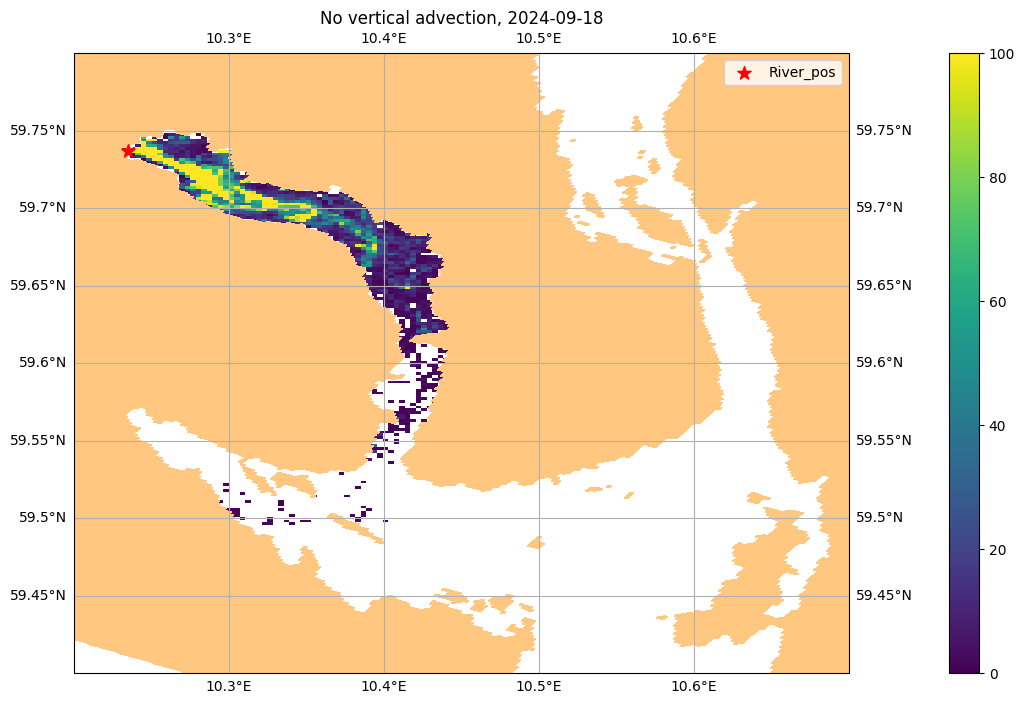

In [30]:

ds = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/drammen/multi_depth_river_plume_2025-09-16T06:00:00.nc')
nk160 = xr.open_dataset('symlink_m71/20240602.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask==1] = np.nan

riv_lon, riv_lat = 10.234757423400879, 59.737117767333984
lon, lat = 10.241, 59.738
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
c = ax.pcolormesh(ds.c_lon, ds.c_lat, ds.number.isel(time=-1), transform=ccrs.PlateCarree(), vmin=0, vmax=100)
#ax.scatter(ds.lon.isel(time=-1), ds.lat.isel(time=-1), transform=ccrs.PlateCarree(), s=2)
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(riv_lon, riv_lat, c='Red', marker='*', s=100, transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([10.2,10.7,59.4,59.8], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)
ax.legend(loc='upper right')
cax = fig.add_axes([ax.get_position().x1+0.1, ax.get_position().y0, 0.030, ax.get_position().height])
cbar = fig.colorbar(c, ax=ax, cax=cax)
ax.set_title('No vertical advection, 2024-09-18')

Text(0.5, 1.0, 'With vertical advection, 2024-09-18')

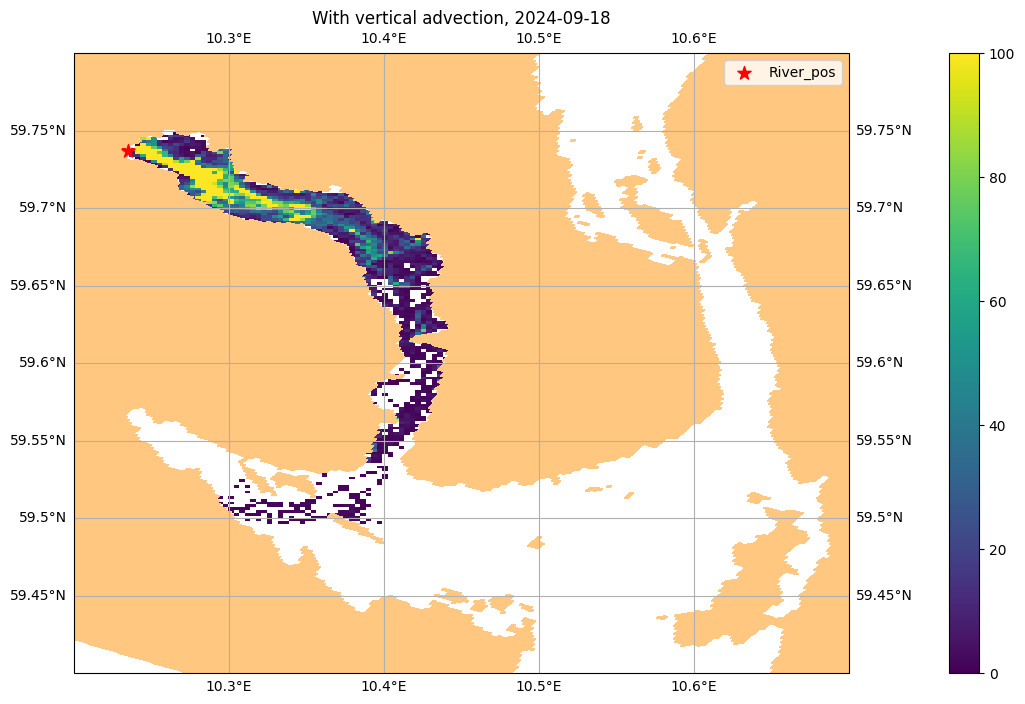

In [99]:

ds = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/drammen/multi_depth_vertical_river_plume_2025-09-16T06:00:00.nc')
nk160 = xr.open_dataset('symlink_m71/20240602.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask==1] = np.nan

riv_lon, riv_lat = 10.234757423400879, 59.737117767333984
lon, lat = 10.241, 59.738
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
c = ax.pcolormesh(ds.c_lon, ds.c_lat, ds.number.isel(time=-1), transform=ccrs.PlateCarree(), vmin=0, vmax=100)
#ax.scatter(ds.lon.isel(time=-1), ds.lat.isel(time=-1), transform=ccrs.PlateCarree(), s=2)
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(riv_lon, riv_lat, c='Red', marker='*', s=100, transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([10.2,10.7,59.4,59.8], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)
ax.legend(loc='upper right')
cax = fig.add_axes([ax.get_position().x1+0.1, ax.get_position().y0, 0.030, ax.get_position().height])
cbar = fig.colorbar(c, ax=ax, cax=cax)
ax.set_title('With vertical advection, 2024-09-18')

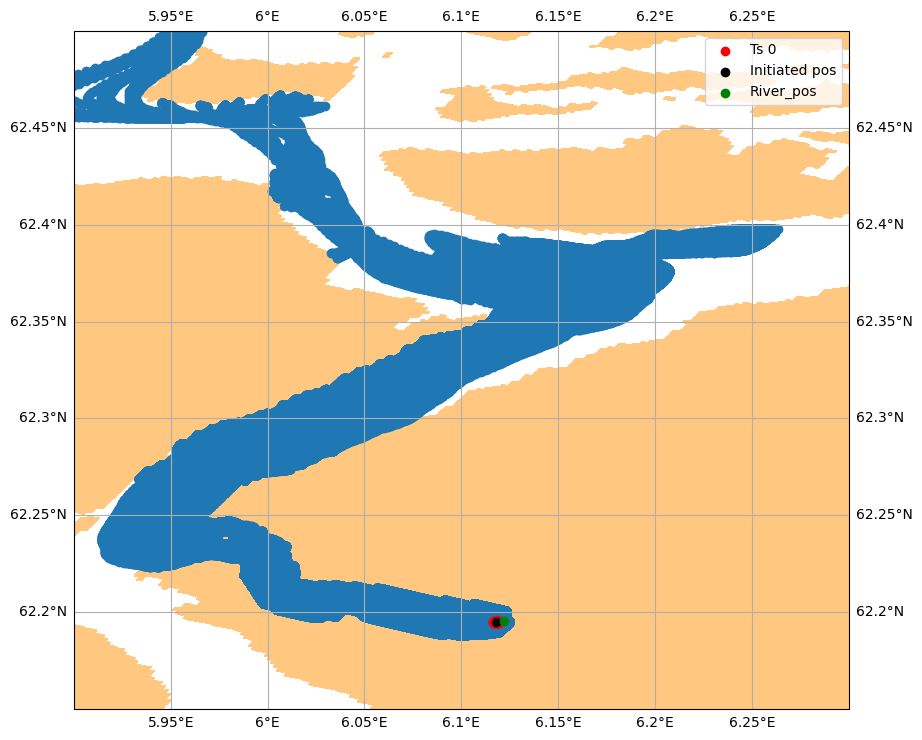

In [4]:
parts = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/orsta/multi_depth_river_plume_2025-11-18T06:00:00.nc')
riv_lon, riv_lat = 6.122272968292236, 62.195274353027344
lon, lat = 6.118, 62.195
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(parts.lon, parts.lat, transform=ccrs.PlateCarree())
ax.scatter(parts.lon.isel(time=0), parts.lat.isel(time=0), c='r', transform=ccrs.PlateCarree(), label='Ts 0')
ax.scatter(lon, lat, c='black', transform=ccrs.PlateCarree(), label='Initiated pos')
ax.scatter(riv_lon, riv_lat, c='green', transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([5.9,6.3,62.15,62.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)
ax.legend(loc='upper right')

Text(0.5, 1.0, 'No vertical advection, 2025-11-18')

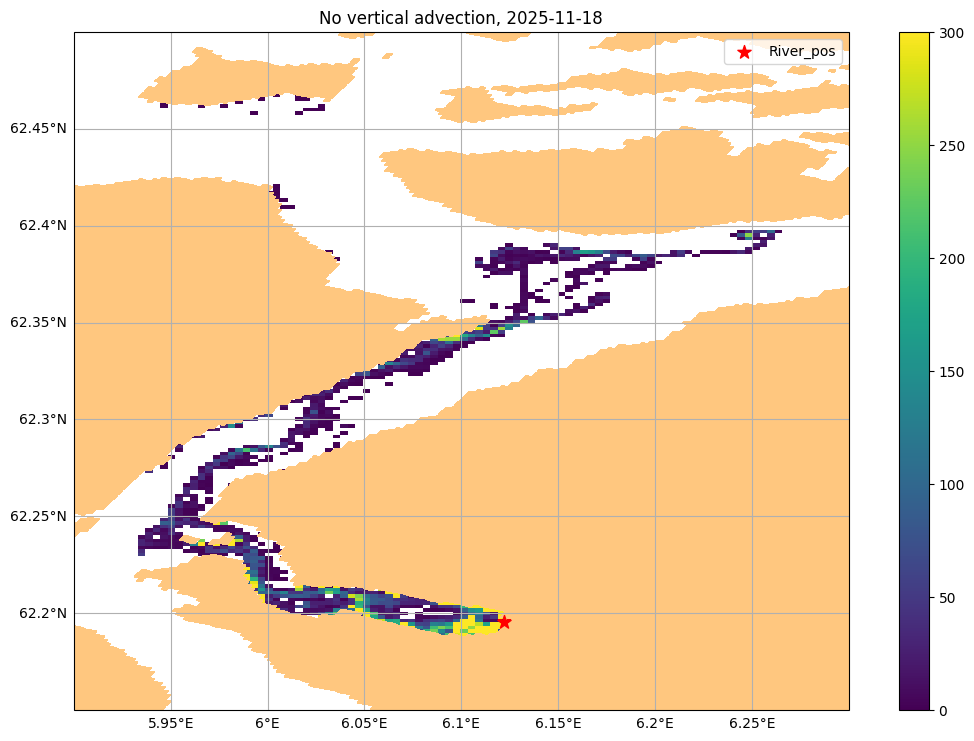

In [3]:

ds = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/orsta/multi_depth_river_plume_2025-11-18T06:00:00.nc')
nk160 = xr.open_dataset('symlink_m70/norkyst160_his_sdepth_20251101T00Z_m70_AN.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask>0] = np.nan

riv_lon, riv_lat = 6.122272968292236, 62.195274353027344
lon, lat = 6.118, 62.195
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
c = ax.pcolormesh(ds.c_lon, ds.c_lat, ds.number.isel(time=-1), transform=ccrs.PlateCarree(), vmin=0, vmax=300)
#ax.scatter(ds.lon.isel(time=-1), ds.lat.isel(time=-1), transform=ccrs.PlateCarree(), s=2)
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(riv_lon, riv_lat, c='Red', marker='*', s=100, transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([5.9,6.3,62.15,62.5], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True)
gl.top_labels = gl.right_labels = False
ax.legend(loc='upper right')
cax = fig.add_axes([ax.get_position().x1+0.05, ax.get_position().y0, 0.030, ax.get_position().height])
cbar = fig.colorbar(c, ax=ax, cax=cax)
ax.set_title('No vertical advection, 2025-11-18')

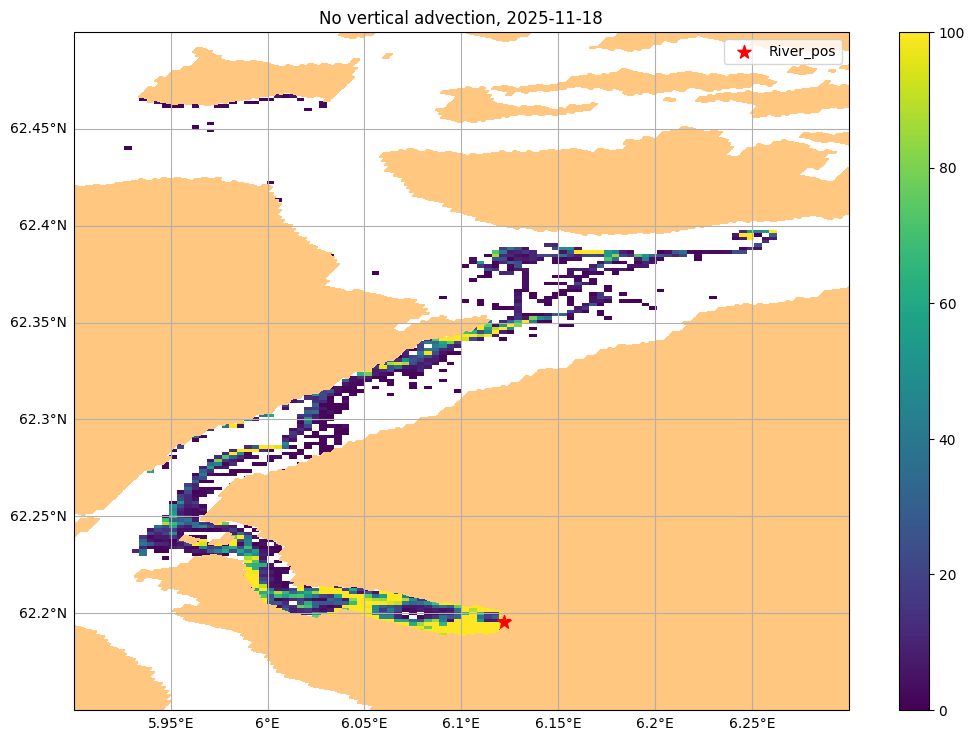

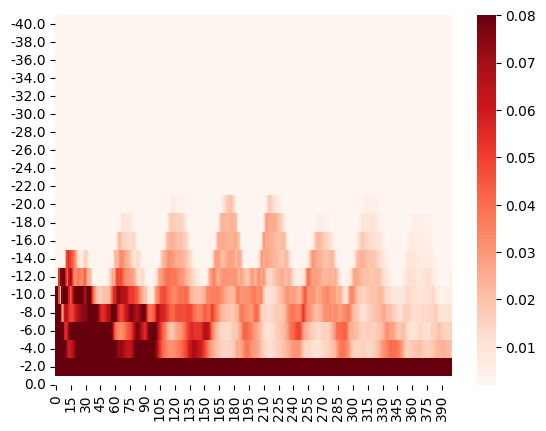

In [22]:
ds = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/orsta/s_multi_depth_vertical_river_plume_2025-11-18T06:00:00.nc')
nk160 = xr.open_dataset('symlink_m70/norkyst160_his_sdepth_20251101T00Z_m70_AN.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask>0] = np.nan

riv_lon, riv_lat = 6.122272968292236, 62.195274353027344
lon, lat = 6.118, 62.195
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
c = ax.pcolormesh(ds.c_lon, ds.c_lat, ds.number.isel(time=-1), transform=ccrs.PlateCarree(), vmin=0, vmax=100)
#ax.scatter(ds.lon.isel(time=-1), ds.lat.isel(time=-1), transform=ccrs.PlateCarree(), s=2)
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(riv_lon, riv_lat, c='Red', marker='*', s=100, transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([5.9,6.3,62.15,62.5], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True)
gl.top_labels = gl.right_labels = False
ax.legend(loc='upper right')
cax = fig.add_axes([ax.get_position().x1+0.05, ax.get_position().y0, 0.030, ax.get_position().height])
cbar = fig.colorbar(c, ax=ax, cax=cax)
ax.set_title('No vertical advection, 2025-11-18')

import seaborn as sns
data = np.zeros([20,len(ds.time)])
for time in range(len(ds.time)):
    hist, bin_edges = np.histogram(ds.z.isel(time=time), bins=20, range=(-40,0), density=True)
    data[:,time] = hist

fig, ax = plt.subplots()
sns.heatmap(data, ax=ax, yticklabels=np.linspace(-40,0,21), vmin=0.002, vmax=0.08, cmap='Reds')
plt.show()



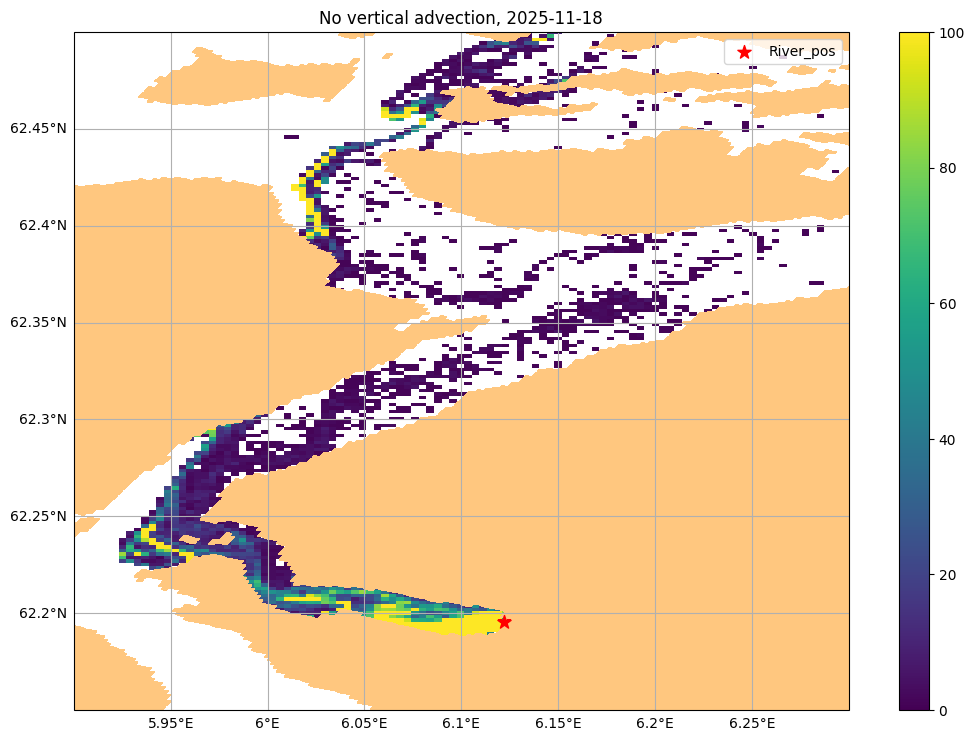

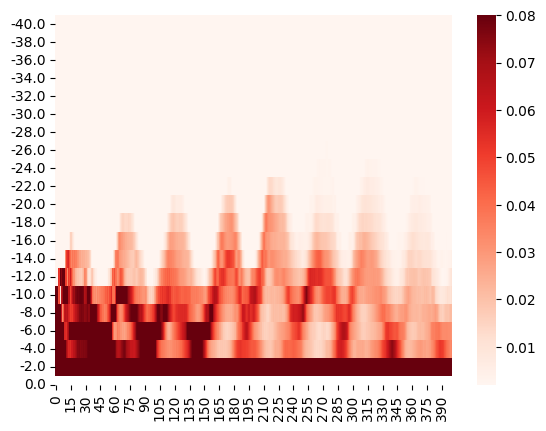

In [21]:
ds = xr.open_dataset('/lustre/storeB/users/mateuszm/RiverPlume/orsta/z_multi_depth_vertical_river_plume_2025-11-18T06:00:00.nc')
nk160 = xr.open_dataset('symlink_m70/norkyst160_his_sdepth_20251101T00Z_m70_AN.nc').isel(ocean_time=4, s_rho=-1)
mask = np.array(nk160.mask_rho)
mask[mask>0] = np.nan

riv_lon, riv_lat = 6.122272968292236, 62.195274353027344
lon, lat = 6.118, 62.195
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
c = ax.pcolormesh(ds.c_lon, ds.c_lat, ds.number.isel(time=-1), transform=ccrs.PlateCarree(), vmin=0, vmax=100)
#ax.scatter(ds.lon.isel(time=-1), ds.lat.isel(time=-1), transform=ccrs.PlateCarree(), s=2)
ax.pcolormesh(nk160.lon_rho, nk160.lat_rho, mask, cmap='copper_r', shading='nearest', transform=ccrs.PlateCarree())
ax.scatter(riv_lon, riv_lat, c='Red', marker='*', s=100, transform=ccrs.PlateCarree(), label='River_pos')
ax.set_extent([5.9,6.3,62.15,62.5], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True)
gl.top_labels = gl.right_labels = False
ax.legend(loc='upper right')
cax = fig.add_axes([ax.get_position().x1+0.05, ax.get_position().y0, 0.030, ax.get_position().height])
cbar = fig.colorbar(c, ax=ax, cax=cax)
ax.set_title('No vertical advection, 2025-11-18')
plt.show()


import seaborn as sns
data = np.zeros([20,len(ds.time)])
for time in range(len(ds.time)):
    hist, bin_edges = np.histogram(ds.z.isel(time=time), bins=20, range=(-40,0), density=True)
    data[:,time] = hist

fig, ax = plt.subplots()
sns.heatmap(data, ax=ax, yticklabels=np.linspace(-40,0,21), vmin=0.002, vmax=0.08, cmap='Reds')
plt.show()